In [4]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd()
# if not (repo_root / "modules").is_dir():
#     repo_root = Path("/home/dpd4k4/SCP")

sys.path.insert(0, str(repo_root))

csv_path = repo_root / "external_data" / "pyrFiringRateAvg.csv"

df = pd.read_csv(csv_path)
df.head()

,Time,AvgFiringRate
0,-0.500000,1.832524
1,-0.494976,1.777913
2,-0.489952,1.910059
3,-0.484928,1.856796
4,-0.479904,1.763754


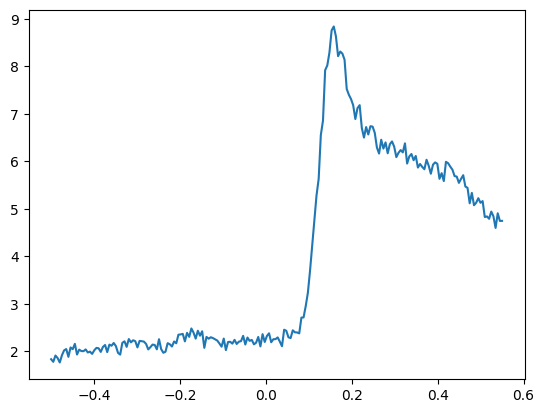

In [7]:
plt.plot(df['Time'], df['AvgFiringRate'])

In [8]:
# This mirrors SCP's CSV preprocessing.

time_ms = df["Time"].to_numpy(dtype=float) * 1000.0
rates_hz = df["AvgFiringRate"].to_numpy(dtype=float)

keep = time_ms >= 0.0
time_ms = time_ms[keep]
rates_hz = rates_hz[keep]

# SCP shifts the first retained sample to time zero.
time_ms = time_ms - time_ms[0]

bin_ms = float(np.median(np.diff(time_ms)))

print(f"CSV: {csv_path.name}")
print(f"Samples retained: {len(rates_hz)}")
print(f"Bin width: {bin_ms:.3f} ms")
print(f"Rate range: {rates_hz.min():.3f} to {rates_hz.max():.3f} Hz")

CSV: pyrFiringRateAvg.csv
Samples retained: 110
Bin width: 5.024 ms
Rate range: 2.106 to 8.841 Hz


In [12]:
# Call SCP's actual custom inhomogeneous Poisson generator.

from modules.input_generation.mode_poisson import _mode_inhomogeneous_poisson

sim_cfg = {
    "tstart": 0.0,
    "tstop": 600.0,
    "seed": 42,
}

group_cfg = {
    "syns": {
        "N_syn": 2000,
    },
    "source": {
        "path": str(csv_path),
        "time_col": "Time",
        "rate_col": "AvgFiringRate",
        "bin_ms": bin_ms,
    },
    "time_cfg": {
        "blocks": [
            {
                "kind": "source",
                "t_start": 0.0,
                "t_end": 600.0,
            }
        ]
    },
}

rng = np.random.default_rng(sim_cfg["seed"])

spike_trains = _mode_inhomogeneous_poisson(
    sim_cfg=sim_cfg,
    group_cfg=group_cfg,
    geometry=None,
    rng=rng,
)

print(f"Generated trains: {len(spike_trains)}")
print(f"Total spikes: {sum(len(train) for train in spike_trains)}")
print("First train:", spike_trains[0][:10])

Generated trains: 2000
Total spikes: 6112
First train: [157.60277404]


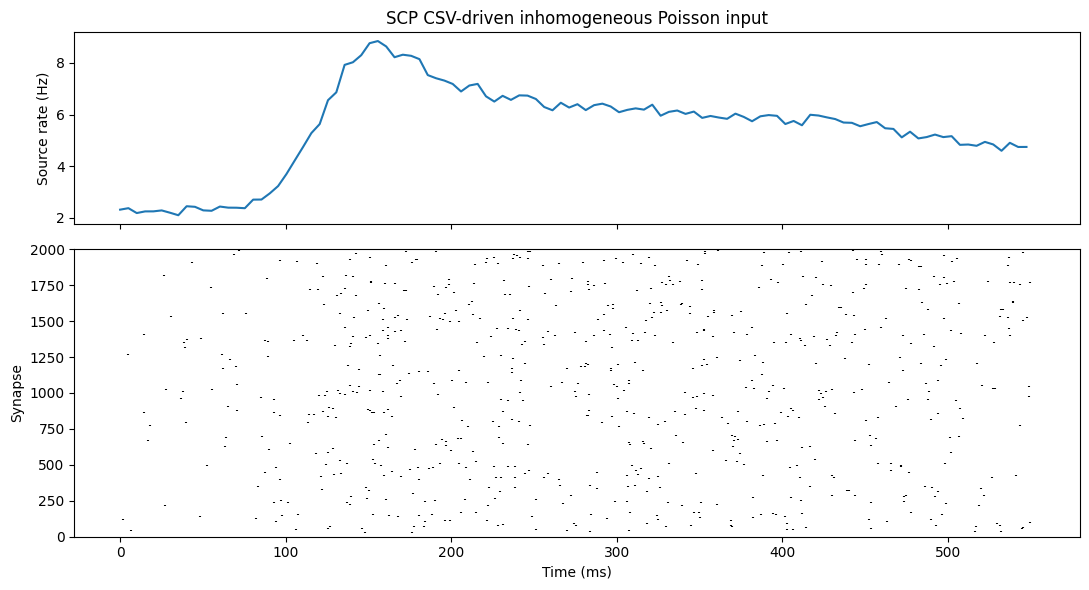

In [13]:
# Plot the source rate and generated raster.

fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1.5]},
)

axes[0].plot(time_ms, rates_hz, color="tab:blue")
axes[0].set_ylabel("Source rate (Hz)")
axes[0].set_title("SCP CSV-driven inhomogeneous Poisson input")

for syn_idx, train in enumerate(spike_trains):
    axes[1].eventplot(
        train,
        lineoffsets=syn_idx,
        linelengths=0.8,
        colors="black",
    )

axes[1].set_ylabel("Synapse")
axes[1].set_xlabel("Time (ms)")
axes[1].set_ylim(-1, len(spike_trains))

plt.tight_layout()
plt.show()

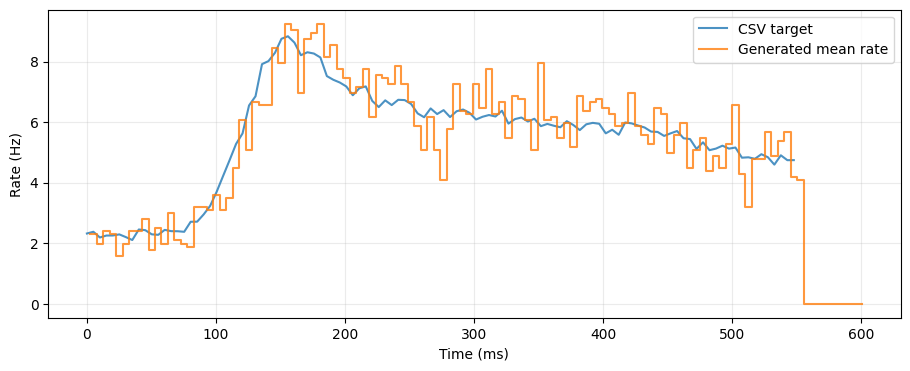

: 

In [ ]:
# Estimate the generated per-synapse rate in the same bins.

edges = np.arange(0.0, 600.0 + bin_ms, bin_ms)
counts = np.zeros(len(edges) - 1)

for train in spike_trains:
    counts += np.histogram(train, bins=edges)[0]

generated_rate_hz = counts / (
    len(spike_trains) * (bin_ms / 1000.0)
)
generated_time_ms = edges[:-1] + bin_ms / 2

plt.figure(figsize=(11, 4))
plt.plot(time_ms, rates_hz, label="CSV target", alpha=0.8)
plt.step(
    generated_time_ms,
    generated_rate_hz,
    where="post",
    label="Generated mean rate",
    alpha=0.8,
)

plt.xlabel("Time (ms)")
plt.ylabel("Rate (Hz)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()